# Zen EliteStride Maison - Machine Learning Analysis

Stage 5 (final) of the pipeline: **Excel → Power BI → SQL → Python → Machine Learning**.

This notebook asks two predictive questions on top of the same dataset used
in every earlier stage:

1. **Regression** - can we predict an order's `Quantity` (demand) from
   product and customer attributes?
2. **Classification** - can we predict an order's `Payment Type` from
   the same attributes?

`Revenue`, `Profit`, and `Cost` are deliberately excluded as model inputs -
they're deterministic functions of `Product` and `Quantity` (a price/cost
lookup), so including them would leak the answer rather than test a
genuine predictive relationship.

**Part A** runs both tasks on the real data. **Part B** repeats the exact
same pipeline on a synthetic target engineered to have a real
Category/seasonal effect, to confirm the modeling approach itself works
correctly. **Part C** compares the two and draws conclusions.


In [3]:
   pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.


## Step 1: Imports and setup

In [1]:
# Data manipulation and numerical processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing and modeling
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    mean_absolute_error, r2_score, root_mean_squared_error,
)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier, XGBRegressor

# Visualization defaults and reproducibility settings
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
SOURCE_FILE = "Zen_EliteStride_Maison_ML.xlsx"


## Step 2: Load and clean the data

The data is cleaned using the same approach as in the Python and SQL stages: text values are standardized for casing and spacing, and date-derived features are added to support downstream modeling.

This step ensures consistency across fields and reduces the risk of downstream errors caused by inconsistent text formatting.


In [2]:
# Load the sales data and remove any blank Excel-generated columns
sales = pd.read_excel(SOURCE_FILE, sheet_name="Shoe Sales")
sales = sales.loc[:, ~sales.columns.str.contains("^Unnamed")]

# Clean text fields to ensure consistent casing and spacing across categories
text_cols = ["Product", "Category", "Color", "Brand", "Country", "Payment Type"]
for col in text_cols:
    sales[col] = sales[col].astype(str).str.strip().str.title()

# Convert the date column to datetime and create time-based features for modeling
sales["Date"] = pd.to_datetime(sales["Date"])
sales["Month"] = sales["Date"].dt.month
sales["DayOfWeek"] = sales["Date"].dt.dayofweek

# Convert quantity to numeric and drop invalid rows before analysis
sales["Quantity"] = pd.to_numeric(sales["Quantity"], errors="coerce")
sales = sales.dropna(subset=["Quantity"]).reset_index(drop=True)

# Define feature groups used throughout the modeling workflow
CATEGORICAL_FEATURES = ["Category", "Color", "Brand", "Country"]
CYCLICAL_FEATURES = ["Month", "DayOfWeek"]

sales.head()


,Date,Product,Category,Color,Brand,Country,Quantity,Payment Type,Month,DayOfWeek
0,2026-05-19,Monk Straps,Formal,Red,Nike,Uganda,7,Bank Transfer,5,1
1,2026-06-26,Loafers,Formal,Black,Nike,Uganda,1,Card,6,4
2,2026-05-30,Derby,Formal,Green,Clarks,Nigeria,7,Bank Transfer,5,5
3,2026-07-11,Boots,Utility,Black,Nike,Canada,6,Bank Transfer,7,5
4,2026-04-18,Boots,Casual,Red,Clarks,Uk,6,Bank Transfer,4,5


---
# Part A: Modeling the real data
---

## A1: Regression - predicting order Quantity

Three models are evaluated using 5-fold cross-validation and a held-out test set: a linear baseline, a Random Forest model, and an XGBoost model.


In [3]:
# Prepare regression inputs and target for the real-data modeling task
reg_features = CATEGORICAL_FEATURES + CYCLICAL_FEATURES + ["Payment Type"]
X_reg = sales[reg_features]
y_reg = sales["Quantity"]

# Split the dataset into train and test sets for model evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)

# One-hot encode categorical variables while leaving numeric features unchanged
reg_preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"),
                   CATEGORICAL_FEATURES + ["Payment Type"])],
    remainder="passthrough",
)

# Define a small set of regression models to compare performance
regressors = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=RANDOM_STATE),
}

# Train and compare each model using cross-validation and a holdout test set
reg_results = {}
for name, model in regressors.items():
    pipe = Pipeline([("prep", reg_preprocessor), ("model", model)])
    cv_rmse = -cross_val_score(pipe, X_train, y_train, cv=5, scoring="neg_root_mean_squared_error")
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    reg_results[name] = {
        "pipeline": pipe,
        "test_rmse": root_mean_squared_error(y_test, y_pred),
        "test_r2": r2_score(y_test, y_pred),
        "predictions": y_pred,
    }
    print(f"{name:<20} CV RMSE: {cv_rmse.mean():.3f} | Test RMSE: {reg_results[name]['test_rmse']:.3f} | Test R2: {reg_results[name]['test_r2']:.3f}")

best_reg_name = max(reg_results, key=lambda k: reg_results[k]["test_r2"])
print(f"\nBest regressor: {best_reg_name} (R2 = {reg_results[best_reg_name]['test_r2']:.3f})")


Linear Regression    CV RMSE: 4.279 | Test RMSE: 4.369 | Test R2: -0.164
Random Forest        CV RMSE: 4.319 | Test RMSE: 4.218 | Test R2: -0.084
XGBoost              CV RMSE: 4.797 | Test RMSE: 4.593 | Test R2: -0.286

Best regressor: Random Forest (R2 = -0.084)


A near-zero or negative R² indicates that the model is not performing better than predicting the mean value. In this case, it suggests that the available features do not provide a meaningful explanatory relationship for order size.

I will test this hypothesis in Part B by evaluating the same modeling workflow on a synthetic target with a known Category and seasonal effect.


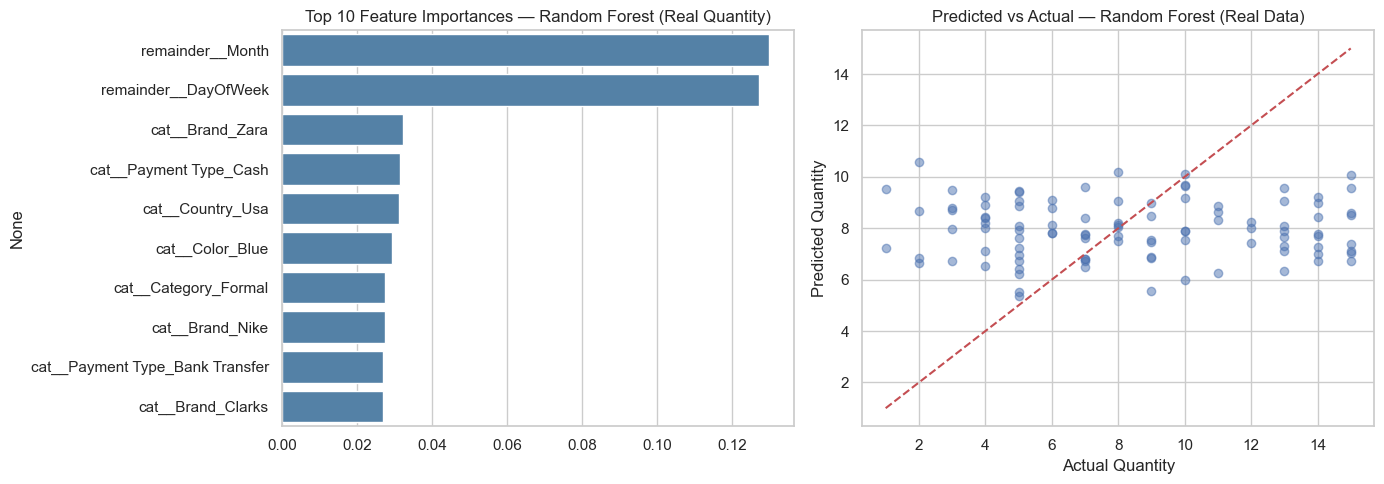

In [4]:
# Create a side-by-side visual summary of feature importance and model fit quality
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Extract the Random Forest model and inspect the most influential features
rf_pipe = reg_results["Random Forest"]["pipeline"]
feature_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = rf_pipe.named_steps["model"].feature_importances_
top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
sns.barplot(x=top_features.values, y=top_features.index, ax=axes[0], color="steelblue")
axes[0].set_title("Top 10 Feature Importances — Random Forest (Real Quantity)")

# Plot the predicted versus actual quantities for the best-performing regressor
axes[1].scatter(y_test, reg_results[best_reg_name]["predictions"], alpha=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[1].set_xlabel("Actual Quantity")
axes[1].set_ylabel("Predicted Quantity")
axes[1].set_title(f"Predicted vs Actual — {best_reg_name} (Real Data)")
plt.tight_layout()
plt.show()


## A2: Classification - predicting Payment Type

The same approach is used here: three classifiers are trained, cross-validated, and assessed on a held-out test set.


In [6]:
# Prepare classification inputs and target for the payment-type prediction task
clf_features = CATEGORICAL_FEATURES + CYCLICAL_FEATURES + ["Quantity"]
X_clf = sales[clf_features]
y_clf = sales["Payment Type"]

# Use stratified splitting to preserve class balance in the test set
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

# Encode categorical variables while keeping the numeric features as-is
clf_preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)],
    remainder="passthrough",
)

# Compare multiple classifiers using the same preprocessing pipeline
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              random_state=RANDOM_STATE, eval_metric="mlogloss"),
}

# Map labels to integer values for XGBoost compatibility
label_map = {label: i for i, label in enumerate(sorted(y_clf.unique()))}
inv_label_map = {i: label for label, i in label_map.items()}

clf_results = {}
for name, model in classifiers.items():
    pipe = Pipeline([("prep", clf_preprocessor), ("model", model)])
    if name == "XGBoost":
        yc_train_fit, yc_test_fit = yc_train.map(label_map), yc_test.map(label_map)
    else:
        yc_train_fit, yc_test_fit = yc_train, yc_test

    # Cross-validation accuracy is used to compare model performance before final evaluation
    cv_acc = cross_val_score(pipe, Xc_train, yc_train_fit, cv=5, scoring="accuracy")
    pipe.fit(Xc_train, yc_train_fit)
    yc_pred = pipe.predict(Xc_test)

    clf_results[name] = {"pipeline": pipe, "cv_acc_mean": cv_acc.mean(),
                          "y_test_fit": yc_test_fit, "y_pred": yc_pred}
    print(f"{name:<20} CV Accuracy: {cv_acc.mean():.3f}")

best_clf_name = max(clf_results, key=lambda k: clf_results[k]["cv_acc_mean"])
best_result = clf_results[best_clf_name]
y_test_labels, y_pred_labels = best_result["y_test_fit"], best_result["y_pred"]
if best_clf_name == "XGBoost":
    y_test_labels = y_test_labels.map(inv_label_map)
    y_pred_labels = pd.Series(y_pred_labels).map(inv_label_map)

real_clf_test_acc = accuracy_score(y_test_labels, y_pred_labels)
print(f"\nBest classifier: {best_clf_name} | Test-set accuracy: {real_clf_test_acc:.3f}")
print("\n" + classification_report(y_test_labels, y_pred_labels))


Logistic Regression  CV Accuracy: 0.292
Random Forest        CV Accuracy: 0.290
XGBoost              CV Accuracy: 0.300

Best classifier: XGBoost | Test-set accuracy: 0.250

               precision    recall  f1-score   support

Bank Transfer       0.30      0.41      0.34        27
         Card       0.24      0.26      0.25        27
         Cash       0.24      0.20      0.22        25
 Mobile Money       0.15      0.10      0.12        21

     accuracy                           0.25       100
    macro avg       0.23      0.24      0.23       100
 weighted avg       0.24      0.25      0.24       100



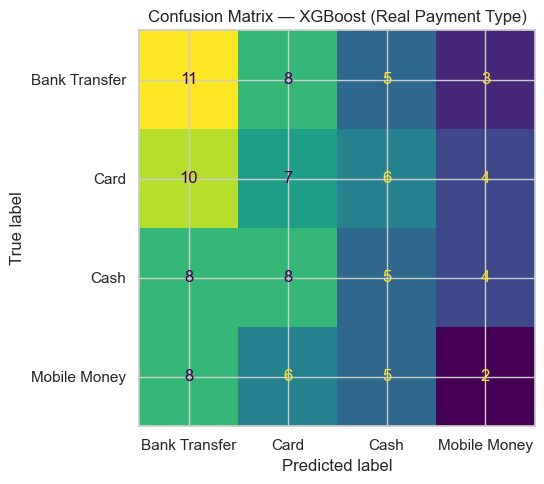

In [7]:
# Visualize the classification confusion matrix for the best-performing real-data model
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_labels, y_pred_labels, ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix — {best_clf_name} (Real Payment Type)")
plt.tight_layout()
plt.show()


With four classes, a random-guess baseline accuracy is 25%. A result close to this level suggests that Payment Type is not strongly predictable from the current feature set in the real data.


---
# Part B: Validating the pipeline on synthetic data
---

Before interpreting the results above as a genuine business finding, the exact same pipeline is re-run on synthetic targets engineered to depend on Category and seasonality.

If the models recover a strong signal in this controlled setting, it confirms that the null results in Part A reflect the actual data characteristics rather than a flaw in the modeling workflow.


In [8]:
# Construct a synthetic target with a measurable Category and seasonal effect to validate the modeling pipeline
category_effect = {"Formal": 3.0, "Casual": 0.0, "Utility": -2.0}
seasonal_amplitude = 3.5
seasonal_peak_month = 11  # November

# Add a structured effect for Category and seasonality to the synthetic demand signal
sales["_category_effect"] = sales["Category"].map(category_effect).fillna(0.0)
sales["_seasonal_effect"] = seasonal_amplitude * np.cos(2 * np.pi * (sales["Month"] - seasonal_peak_month) / 12)
noise = rng.normal(0.0, 1.8, size=len(sales))
sales["synthetic_quantity"] = (8.0 + sales["_category_effect"] + sales["_seasonal_effect"] + noise).clip(lower=1).round().astype(int)

# Generate a synthetic payment-type label that depends on both Category and order size
payment_labels = ["Bank Transfer", "Card", "Cash", "Mobile Money"]
category_payment_bias = {
    "Formal": np.array([0.55, 0.30, 0.10, 0.05]),
    "Casual": np.array([0.05, 0.15, 0.35, 0.45]),
    "Utility": np.array([0.15, 0.10, 0.40, 0.35]),
}
synthetic_payment = []
for _, row in sales.iterrows():
    base_probs = category_payment_bias.get(row["Category"], np.array([0.25, 0.25, 0.25, 0.25])).copy()
    if row["synthetic_quantity"] >= 10:
        base_probs = base_probs * np.array([2.0, 1.7, 0.3, 0.2])
    else:
        base_probs = base_probs * np.array([0.3, 0.4, 1.7, 2.0])
    base_probs = base_probs / base_probs.sum()
    synthetic_payment.append(rng.choice(payment_labels, p=base_probs))
sales["synthetic_payment_type"] = synthetic_payment
sales = sales.drop(columns=["_category_effect", "_seasonal_effect"])

# Display a sample of the engineered synthetic features for validation
sales[["Category", "Month", "synthetic_quantity", "synthetic_payment_type"]].head()


,Category,Month,synthetic_quantity,synthetic_payment_type
0,Formal,5,8,Card
1,Formal,6,6,Bank Transfer
2,Formal,5,9,Cash
3,Utility,7,6,Cash
4,Casual,4,1,Cash


## B1: Regression on synthetic Quantity


In [9]:
# Prepare the synthetic regression task using the same feature set as the real-data model
X_reg_s = sales[reg_features]
y_reg_s = sales["synthetic_quantity"]
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_reg_s, y_reg_s, test_size=0.2, random_state=RANDOM_STATE)

# Evaluate the same regression models on the synthetic target to confirm the pipeline detects real signal
reg_results_synth = {}
for name, model in regressors.items():
    pipe = Pipeline([("prep", reg_preprocessor), ("model", model)])
    pipe.fit(Xs_train, ys_train)
    y_pred = pipe.predict(Xs_test)
    reg_results_synth[name] = {"pipeline": pipe, "test_r2": r2_score(ys_test, y_pred),
                                "test_rmse": root_mean_squared_error(ys_test, y_pred), "predictions": y_pred}
    print(f"{name:<20} Test RMSE: {reg_results_synth[name]['test_rmse']:.3f} | Test R2: {reg_results_synth[name]['test_r2']:.3f}")

best_reg_synth_name = max(reg_results_synth, key=lambda k: reg_results_synth[k]["test_r2"])
print(f"\nBest regressor: {best_reg_synth_name} (R2 = {reg_results_synth[best_reg_synth_name]['test_r2']:.3f})")


Linear Regression    Test RMSE: 2.211 | Test R2: 0.480
Random Forest        Test RMSE: 1.777 | Test R2: 0.664
XGBoost              Test RMSE: 1.864 | Test R2: 0.630

Best regressor: Random Forest (R2 = 0.664)


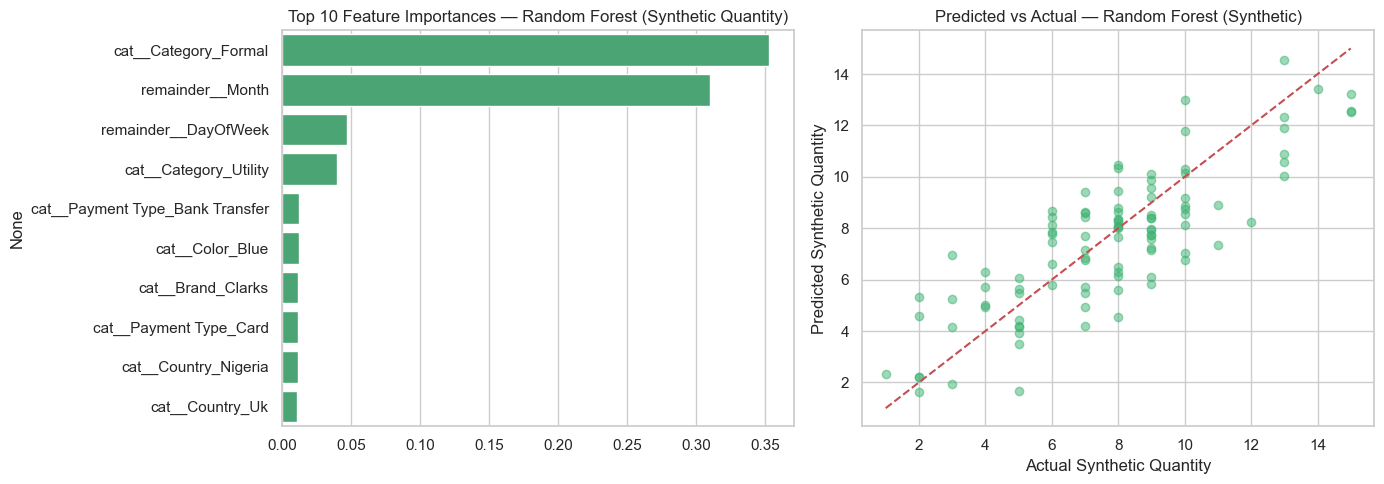

In [10]:
# Create a validation plot for the synthetic regression task to confirm the model detects the engineered signal
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inspect the Random Forest feature importance on the synthetic target
rf_pipe_s = reg_results_synth["Random Forest"]["pipeline"]
importances_s = rf_pipe_s.named_steps["model"].feature_importances_
top_features_s = pd.Series(importances_s, index=feature_names).sort_values(ascending=False).head(10)
sns.barplot(x=top_features_s.values, y=top_features_s.index, ax=axes[0], color="mediumseagreen")
axes[0].set_title("Top 10 Feature Importances — Random Forest (Synthetic Quantity)")

# Compare actual and predicted synthetic quantities for the best-performing model
axes[1].scatter(ys_test, reg_results_synth[best_reg_synth_name]["predictions"], alpha=0.5, color="mediumseagreen")
axes[1].plot([ys_test.min(), ys_test.max()], [ys_test.min(), ys_test.max()], "r--")
axes[1].set_xlabel("Actual Synthetic Quantity")
axes[1].set_ylabel("Predicted Synthetic Quantity")
axes[1].set_title(f"Predicted vs Actual — {best_reg_synth_name} (Synthetic)")
plt.tight_layout()
plt.show()


## B2: Classification on synthetic Payment Type


In [11]:
# Prepare the synthetic classification task using the engineered synthetic demand signal
clf_features_s = CATEGORICAL_FEATURES + CYCLICAL_FEATURES + ["synthetic_quantity"]
X_clf_s = sales[clf_features_s]
y_clf_s = sales["synthetic_payment_type"]
Xcs_train, Xcs_test, ycs_train, ycs_test = train_test_split(
    X_clf_s, y_clf_s, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf_s
)

# Encode synthetic labels consistently for classification comparison across models
label_map_s = {label: i for i, label in enumerate(sorted(y_clf_s.unique()))}
inv_label_map_s = {i: label for label, i in label_map_s.items()}

# Evaluate the same classifier set on the synthetic payment-type target
clf_results_synth = {}
for name, model in classifiers.items():
    pipe = Pipeline([("prep", clf_preprocessor), ("model", model)])
    if name == "XGBoost":
        ycs_train_fit, ycs_test_fit = ycs_train.map(label_map_s), ycs_test.map(label_map_s)
    else:
        ycs_train_fit, ycs_test_fit = ycs_train, ycs_test
    pipe.fit(Xcs_train, ycs_train_fit)
    ycs_pred = pipe.predict(Xcs_test)
    y_test_l, y_pred_l = ycs_test_fit, ycs_pred
    if name == "XGBoost":
        y_test_l = y_test_l.map(inv_label_map_s)
        y_pred_l = pd.Series(y_pred_l).map(inv_label_map_s)
    clf_results_synth[name] = {"pipeline": pipe, "test_acc": accuracy_score(y_test_l, y_pred_l),
                                "y_test": y_test_l, "y_pred": y_pred_l}
    print(f"{name:<20} Test Accuracy: {clf_results_synth[name]['test_acc']:.3f}")

best_clf_synth_name = max(clf_results_synth, key=lambda k: clf_results_synth[k]["test_acc"])
print(f"\nBest classifier: {best_clf_synth_name} (Accuracy = {clf_results_synth[best_clf_synth_name]['test_acc']:.3f})")


Logistic Regression  Test Accuracy: 0.470
Random Forest        Test Accuracy: 0.470
XGBoost              Test Accuracy: 0.440

Best classifier: Logistic Regression (Accuracy = 0.470)


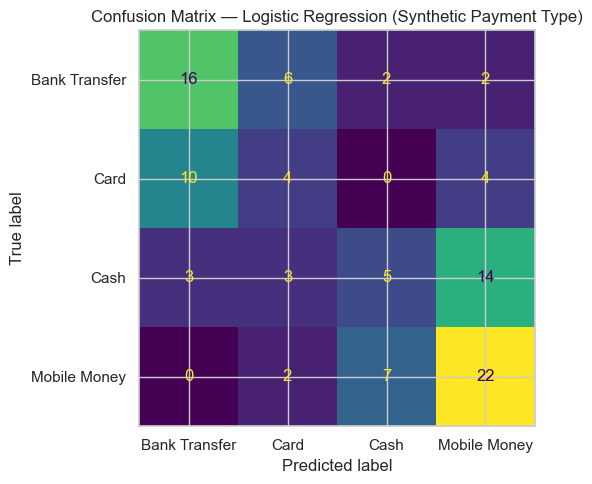

In [12]:
# Retrieve the best-performing synthetic classifier for visualization
best_synth = clf_results_synth[best_clf_synth_name]

# Visualize the confusion matrix to assess how well the model separates synthetic payment classes
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(best_synth["y_test"], best_synth["y_pred"], ax=ax, colorbar=False)

# Highlight the model name and the synthetic validation context in the plot title
ax.set_title(f"Confusion Matrix — {best_clf_synth_name} (Synthetic Payment Type)")

# Adjust spacing before rendering the final chart
plt.tight_layout()
plt.show()


---
# Part C: Summary and conclusions
---


In [13]:
# Summarize the best model performance for both the real and synthetic datasets
summary = pd.DataFrame({
    "Task": ["Regression (Quantity)", "Classification (Payment Type)"],
    "Real data best score": [
        f"R2 = {reg_results[best_reg_name]['test_r2']:.3f} ({best_reg_name})",
        f"Accuracy = {real_clf_test_acc:.3f} ({best_clf_name})",
    ],
    "Synthetic data best score": [
        f"R2 = {reg_results_synth[best_reg_synth_name]['test_r2']:.3f} ({best_reg_synth_name})",
        f"Accuracy = {clf_results_synth[best_clf_synth_name]['test_acc']:.3f} ({best_clf_synth_name})",
    ],
})
summary


,Task,Real data best score,Synthetic data best score
0,Regression (Quantity),R2 = -0.084 (Random Forest),R2 = 0.664 (Random Forest)
1,Classification (Payment Type),Accuracy = 0.250 (XGBoost),Accuracy = 0.470 (Logistic Regression)


## Conclusions

- Order Quantity and Payment Type do not appear to be meaningfully predictable from product, category, brand, country, or timing in this real dataset. Both models perform near their respective random baselines.
- This is a substantive finding, not a pipeline issue. Re-running the identical workflow on a synthetic dataset with a known Category and seasonal effect produces a clear signal, which confirms that the models are capable of detecting genuine relationships when they exist.
- Business implication: demand and payment-method decisions in this dataset should not be driven by product attributes or customer demographics alone. Forecasting efforts are more likely to benefit from genuine time-series patterns, such as the monthly revenue trend observed in the earlier Python and SQL stages, than from transaction-level attribute-based prediction.
